# FinChatbot V2 — Colab Version

## Before running:
1. **Runtime → Change runtime type → T4 GPU** (optional but faster)
2. Upload these 4 files to `/content/` using the Files panel on the left:

| File | Size | Where to get it |
|---|---|---|
| `minilm_finetuned.zip` | 80MB | `fine_tuning/minilm_finetuned/minilm_finetuned.zip` |
| `intent_classifier_model.zip` | 80MB | `final_chatbot/intent_classifier_model.zip` |
| `s4_corpus.csv` | 14MB | `fine_tuning/s4_corpus.csv` |
| `test_set.json` | 24KB | `final_chatbot/chatbot_results/test_set.json` |

3. Paste your OpenRouter API key in **Cell 2**
4. Run all cells in order

## Pipeline
```
Query → Intent Classifier → Fine-Tuned MiniLM → FAISS → Cross-Encoder → LLaMA Answer → DeBERTa Confidence
```

In [1]:
# ── Cell 1: Install ────────────────────────────────────────────────────────────
!pip install -q sentence-transformers faiss-cpu transformers openai tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 90.8 MB/s eta 0:00:00


In [3]:
# ── Cell 2: Config — PASTE YOUR API KEY HERE ───────────────────────────────────
OPENROUTER_API_KEY = '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'

# ── Paths (Colab) ──────────────────────────────────────────────────────────────
import os
S4_CORPUS_PATH    = '/content/s4_corpus.csv'
FT_MODEL_PATH     = '/content/minilm_finetuned'
INTENT_MODEL_PATH = '/content/minilm_intent_classifier'
TEST_SET_PATH     = '/content/test_set.json'
RESULTS_DIR       = '/content/chatbot_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

assert OPENROUTER_API_KEY != 'sk-or-v1-PASTE-YOUR-KEY-HERE', 'Paste your OpenRouter API key above!'
print('Config OK')
print(f'API key: ...{OPENROUTER_API_KEY[-6:]}')

Config OK
API key: ...c27214


In [5]:
# ── Cell 3: Unzip Models ───────────────────────────────────────────────────────
import os

# Unzip fine-tuned MiniLM
if not os.path.exists(FT_MODEL_PATH):
    print('Unzipping minilm_finetuned.zip...')
    !unzip -q /content/minilm_finetuned.zip -d /content/minilm_finetuned
    print('  Done')
else:
    print('minilm_finetuned already unzipped')

# Unzip intent classifier
if not os.path.exists(INTENT_MODEL_PATH):
    print('Unzipping intent_classifier_model.zip...')
    os.makedirs(INTENT_MODEL_PATH, exist_ok=True)
    !unzip -q /content/intent_classifier_model.zip -d /content/minilm_intent_classifier
    print('  Done')
else:
    print('intent_classifier already unzipped')

# Verify all files present
for path in [S4_CORPUS_PATH, FT_MODEL_PATH, INTENT_MODEL_PATH, TEST_SET_PATH]:
    status = '✅' if os.path.exists(path) else '❌ MISSING'
    print(f'  {status}  {path}')

minilm_finetuned already unzipped
intent_classifier already unzipped
  ✅  /content/s4_corpus.csv
  ✅  /content/minilm_finetuned
  ✅  /content/minilm_intent_classifier
  ✅  /content/test_set.json


In [6]:
# ── Cell 4: Imports ────────────────────────────────────────────────────────────
import gc, json, time, re
import numpy as np
import pandas as pd
import faiss
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from openai import OpenAI
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer, CrossEncoder

client = OpenAI(api_key=OPENROUTER_API_KEY, base_url='https://openrouter.ai/api/v1')

LLAMA_MODEL   = 'meta-llama/llama-3.3-70b-instruct'
CE_MODEL_NAME = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
NLI_MODEL     = 'cross-encoder/nli-deberta-v3-small'

CATEGORIES = ['Regulatory', 'Consumer_Protection', 'Payment_Industry', 'Synthetic_Policies']
LABEL2ID   = {c: i for i, c in enumerate(CATEGORIES)}
ID2LABEL   = {i: c for c, i in LABEL2ID.items()}

OOS_CONFIDENCE_THRESHOLD = 0.60
CONF_HIGH   = 0.70
CONF_MEDIUM = 0.40

print('Imports OK')
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

Imports OK
Device: cuda


In [7]:
# ── Cell 5: Load Models + FAISS ────────────────────────────────────────────────
print('Loading Intent Classifier...')
intent_tokenizer = AutoTokenizer.from_pretrained(INTENT_MODEL_PATH)
intent_model     = AutoModelForSequenceClassification.from_pretrained(INTENT_MODEL_PATH)
intent_model.eval()
print('  OK')

print('Loading Fine-Tuned MiniLM...')
ft_model = SentenceTransformer(FT_MODEL_PATH)
print('  OK')

print('Loading Cross-Encoder...')
ce_model = CrossEncoder(CE_MODEL_NAME, max_length=512)
print('  OK')

print('\nBuilding FAISS index...')
corpus_df    = pd.read_csv(S4_CORPUS_PATH)
corpus_texts = corpus_df['text'].tolist()
corpus_ids   = corpus_df['chunk_id'].tolist()
print(f'  Corpus: {len(corpus_texts):,} chunks')

corpus_embs = ft_model.encode(
    corpus_texts, batch_size=256,
    normalize_embeddings=True,
    show_progress_bar=True,
    convert_to_numpy=True,
).astype(np.float32)

faiss_index = faiss.IndexFlatIP(corpus_embs.shape[1])
faiss_index.add(corpus_embs)
print(f'  FAISS index: {faiss_index.ntotal:,} vectors')

# Free embeddings after index is built
del corpus_embs
gc.collect()
print('  Corpus embeddings freed')

print('\nLoading DeBERTa NLI...')
nli_model = CrossEncoder(NLI_MODEL, default_activation_function=None)
print('  OK')
print('\nAll models ready.')

Loading Intent Classifier...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

  OK
Loading Fine-Tuned MiniLM...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  OK
Loading Cross-Encoder...


...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

  OK

All models ready.


In [8]:
# ── Cell 6: Prompts ────────────────────────────────────────────────────────────
ANSWER_SYSTEM_PROMPT = """You are FinSearch, a warm, professional, and empathetic financial document assistant.
You help users understand financial regulations, payment industry standards, consumer protection policies, and related financial topics.

Your core principles:
1. EMPATHY FIRST: Open with a brief, genuine acknowledgment of the user's question. Financial topics can be complex and stressful — show you understand.
2. ACCURACY ONLY: Base your answer exclusively on the provided document excerpts. Never fabricate, assume, or use outside knowledge.
3. CITE EVERYTHING: After every key fact or claim, add a citation in the format [Source: <document_name>].
4. PLAIN LANGUAGE: Avoid unnecessary jargon. When technical terms are unavoidable, briefly explain them.
5. HONEST LIMITATIONS: If the documents do not fully answer the question, say so honestly rather than guessing.
6. WARM CLOSE: End with a genuine, warm offer to help further or clarify anything.

Response structure:
- One empathetic opening sentence acknowledging the question
- Clear, well-structured answer with inline citations [Source: ...]
- If helpful, a brief practical implication for the user
- A warm closing offer to assist further

The document excerpts provided are your ONLY source of truth."""

ANSWER_USER_PROMPT = """Please answer the user's question based on the document excerpts below.

Document Excerpts:
{context}

User Question: {question}

Remember: cite every key claim with [Source: <document_name>], maintain an empathetic and professional tone, and close warmly."""

OOS_RESPONSE = """Thank you so much for reaching out to FinSearch.

I appreciate you taking the time to ask, and I want to be completely transparent with you — your question falls outside the areas I'm trained to assist with. I specialise in financial regulations, payment industry standards, consumer protection policies, and related financial document topics.

I genuinely wouldn't want to provide you with inaccurate or incomplete guidance on something outside my expertise. For the best and most reliable help, I'd warmly recommend speaking with a qualified human advisor who can give your question the personalised attention it deserves.

If you have any questions about financial regulations, payment standards, consumer protection, or related policies — I'm right here and happy to help!"""

CONF_MEDIUM_PREFIX = (
    "I want to be transparent — my confidence in this answer is moderate, "
    "as the available documents provide only partial coverage of your question. "
    "I'd encourage you to verify the details with a specialist or review the source documents directly.\n\n"
)
CONF_LOW_PREFIX = (
    "⚠️ I must be honest with you — I have low confidence in this answer. "
    "The documents in my knowledge base do not appear to cover this topic sufficiently. "
    "Please treat the following as a starting point only and verify with a qualified human advisor before taking any action.\n\n"
)

print('All prompts defined.')

All prompts defined.


In [9]:
# ── Cell 7: Pipeline Functions ─────────────────────────────────────────────────

def classify_intent(query):
    inputs = intent_tokenizer(
        query, return_tensors='pt', truncation=True, max_length=128, padding=True
    )
    with torch.no_grad():
        logits = intent_model(**inputs).logits
    probs      = torch.softmax(logits, dim=-1).squeeze().numpy()
    pred_id    = int(np.argmax(probs))
    confidence = float(probs[pred_id])
    category   = ID2LABEL[pred_id]
    is_oos     = confidence < OOS_CONFIDENCE_THRESHOLD
    return category, confidence, is_oos


def retrieve(query, top_k=20):
    q_emb = ft_model.encode(
        [query], normalize_embeddings=True, convert_to_numpy=True
    ).astype(np.float32)
    scores, indices = faiss_index.search(q_emb, top_k)
    return [{'chunk_id': corpus_ids[idx], 'text': corpus_texts[idx], 'ret_score': float(score)}
            for idx, score in zip(indices[0], scores[0])]


def rerank(query, candidates, top_k=3):
    pairs  = [(query, c['text']) for c in candidates]
    scores = ce_model.predict(pairs).tolist()
    ranked = sorted(zip(scores, candidates), key=lambda x: x[0], reverse=True)
    return [c for _, c in ranked[:top_k]]


def compute_confidence(answer, top_chunks, ret_scores):
    s_min, s_max   = min(ret_scores), max(ret_scores)
    norm           = [(s - s_min) / (s_max - s_min + 1e-9) for s in ret_scores]
    retrieval_conf = float(np.mean(norm))
    entailment_scores = []
    for chunk in top_chunks:
        logits = nli_model.predict([[chunk['text'][:500], answer]])
        probs  = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
        entailment_scores.append(float(probs[0][2]))  # index 2 = entailment
    faithfulness_conf = float(np.mean(entailment_scores)) if entailment_scores else 0.0
    final_conf = round(0.4 * retrieval_conf + 0.6 * faithfulness_conf, 4)
    label = 'HIGH' if final_conf >= CONF_HIGH else ('MEDIUM' if final_conf >= CONF_MEDIUM else 'LOW')
    return {'retrieval_confidence': round(retrieval_conf, 4),
            'faithfulness_confidence': round(faithfulness_conf, 4),
            'final_confidence': final_conf, 'label': label}


def generate_answer(query, top_chunks, retry=2):
    context_parts = []
    for i, chunk in enumerate(top_chunks):
        doc_name = chunk['chunk_id'].rsplit('_chunk_', 1)[0]
        context_parts.append(f'[{i+1}] Document: {doc_name}\n{chunk["text"]}')
    context  = '\n\n'.join(context_parts)
    user_msg = ANSWER_USER_PROMPT.format(context=context, question=query)
    for attempt in range(retry + 1):
        try:
            resp = client.chat.completions.create(
                model=LLAMA_MODEL,
                messages=[
                    {'role': 'system', 'content': ANSWER_SYSTEM_PROMPT},
                    {'role': 'user',   'content': user_msg},
                ],
                max_tokens=600, temperature=0.1,
            )
            return resp.choices[0].message.content.strip(), context
        except Exception as e:
            if attempt == retry:
                return 'I apologise — I encountered a technical issue. Please try again shortly.', ''
            time.sleep(2)


def chatbot(query, verbose=True):
    result = {'query': query}
    category, intent_conf, is_oos = classify_intent(query)
    result.update({'intent': category, 'intent_conf': intent_conf, 'is_oos': is_oos})

    if is_oos:
        result.update({'response': OOS_RESPONSE, 'answer': OOS_RESPONSE,
                       'top_chunks': [], 'confidence': None, 'oos_handled': True})
        if verbose: print(f'[OOS] Intent: {category} ({intent_conf:.2f}) → Polite refusal sent.')
        return result

    candidates = retrieve(query, top_k=20)
    top_chunks = rerank(query, candidates, top_k=3)
    raw_answer, context = generate_answer(query, top_chunks)
    ret_scores = [c['ret_score'] for c in top_chunks]
    conf       = compute_confidence(raw_answer, top_chunks, ret_scores)

    if conf['label'] == 'MEDIUM':
        final_response = CONF_MEDIUM_PREFIX + raw_answer
    elif conf['label'] == 'LOW':
        final_response = CONF_LOW_PREFIX + raw_answer
    else:
        final_response = raw_answer

    result.update({'answer': raw_answer, 'response': final_response,
                   'top_chunks': top_chunks, 'context': context,
                   'confidence': conf, 'oos_handled': False})
    if verbose:
        print(f'[{category}] Intent conf: {intent_conf:.2f}')
        print(f'Confidence  : {conf["final_confidence"]} ({conf["label"]})')
    return result

print('All pipeline functions defined.')

All pipeline functions defined.


In [10]:
# ── Cell 8: Load Test Set from Disk ───────────────────────────────────────────
with open(TEST_SET_PATH) as f:
    test_records = json.load(f)
test_df = pd.DataFrame(test_records)

print(f'✅ Test set loaded: {len(test_df)} questions')
print(test_df['category'].value_counts().to_string())
print(f'\nSample: {test_df.iloc[0]["question"]}')

✅ Test set loaded: 30 questions
category
Regulatory             6
Consumer_Protection    6
Payment_Industry       6
Synthetic_Policies     6
OOS                    6

Sample: How does a creditor determine the interest rate for disclosure purposes when calculating the minimum payment, and what factors do they consider? What if there's no lifetime interest rate cap on the loan?


In [11]:
# ── Cell 9: Run Chatbot on All 30 Questions ────────────────────────────────────
# Resume-safe: saves after each query — if interrupted, re-run this cell to continue
responses_path = os.path.join(RESULTS_DIR, 'chatbot_responses.json')

# Load existing progress if any
if os.path.exists(responses_path):
    with open(responses_path) as f:
        chatbot_results = json.load(f)
    done_indices = {r['idx'] for r in chatbot_results}
    print(f'Resuming from {len(done_indices)} already-done queries...')
else:
    chatbot_results = []
    done_indices    = set()

for i, row in enumerate(tqdm(test_df.itertuples(), total=len(test_df), desc='Chatbot')):
    if i in done_indices:
        continue
    print(f'\n[{i+1}/{len(test_df)}] {row.category}: {row.question[:70]}...' if len(row.question) > 70 else f'\n[{i+1}/{len(test_df)}] {row.category}: {row.question}')

    result = chatbot(row.question, verbose=True)
    chatbot_results.append({
        'idx'             : i,
        'category'        : row.category,
        'question'        : row.question,
        'expected_answer' : row.expected_answer,
        'chatbot_response': result['response'],
        'raw_answer'      : result.get('answer', ''),
        'intent_predicted': result['intent'],
        'intent_conf'     : result['intent_conf'],
        'is_oos_predicted': result['is_oos'],
        'is_oos_true'     : bool(row.is_oos),
        'confidence'      : result.get('confidence'),
        'top_chunk_ids'   : [c['chunk_id'] for c in result.get('top_chunks', [])],
    })
    # Save after every query
    with open(responses_path, 'w') as f:
        json.dump(chatbot_results, f, indent=2)

in_scope_results = [r for r in chatbot_results if not r['is_oos_true']]
high_conf = sum(1 for r in in_scope_results if r.get('confidence') and r['confidence']['label'] == 'HIGH')
med_conf  = sum(1 for r in in_scope_results if r.get('confidence') and r['confidence']['label'] == 'MEDIUM')
low_conf  = sum(1 for r in in_scope_results if r.get('confidence') and r['confidence']['label'] == 'LOW')

print(f'\n✅ All {len(chatbot_results)} responses saved to {responses_path}')
print(f'Confidence — HIGH: {high_conf}  MEDIUM: {med_conf}  LOW: {low_conf}')

Chatbot:   0%|          | 0/30 [00:00<?, ?it/s]


[1/30] Regulatory: How does a creditor determine the interest rate for disclosure purpose...


Chatbot:   3%|▎         | 1/30 [00:18<09:04, 18.76s/it]

[Regulatory] Intent conf: 0.87
Confidence  : 0.5613 (MEDIUM)

[2/30] Regulatory: What are the requirements for disclosing late payment fees and penalty...


Chatbot:   7%|▋         | 2/30 [00:37<08:45, 18.78s/it]

...

[Payment_Industry] Intent conf: 0.71
Confidence  : 0.7318 (HIGH)

[24/30] Synthetic_Policies: What are the minimum opening balance requirements for different types ...


Chatbot:  80%|████████  | 24/30 [04:17<00:47,  7.86s/it]

[Regulatory] Intent conf: 0.83
Confidence  : 0.7556 (HIGH)

[25/30] OOS: What are the best hiking trails in the Rocky Mountains?
[OOS] Intent: Synthetic_Policies (0.46) → Polite refusal sent.

[26/30] OOS: How do I make a perfect chicken parmesan?
[OOS] Intent: Payment_Industry (0.51) → Polite refusal sent.

[27/30] OOS: What is the average airspeed velocity of a Boeing 747?


Chatbot: 100%|██████████| 30/30 [04:19<00:00,  8.64s/it]

[Payment_Industry] Intent conf: 0.67
Confidence  : 0.6514 (MEDIUM)

[28/30] OOS: Can you recommend a good recipe for vegan chocolate cake?
[OOS] Intent: Payment_Industry (0.52) → Polite refusal sent.

[29/30] OOS: What are the symptoms of a broken ankle?
[OOS] Intent: Synthetic_Policies (0.49) → Polite refusal sent.

[30/30] OOS: How do I get rid of a stubborn stain on my carpet?
[OOS] Intent: Consumer_Protection (0.60) → Polite refusal sent.

✅ All 30 responses saved to /content/chatbot_results/chatbot_responses.json
Confidence — HIGH: 11  MEDIUM: 5  LOW: 3


In [12]:
# ── Cell 10: LLM-as-Judge ──────────────────────────────────────────────────────
# Resume-safe: re-run if interrupted
judged_path = os.path.join(RESULTS_DIR, 'judged_results.json')

if os.path.exists(judged_path):
    with open(judged_path) as f:
        judged_results = json.load(f)
    done_judge = {r['idx'] for r in judged_results}
    print(f'Resuming judge from {len(done_judge)} done...')
else:
    judged_results = []
    done_judge     = set()

JUDGE_PROMPT = """You are an expert evaluator assessing a financial chatbot's response quality.

Question: {question}
Expected Answer: {expected_answer}
Chatbot Response: {chatbot_response}

Score on these dimensions:
1. Faithfulness (1-5): Is the response factually accurate and supported by the expected answer?
   5=fully accurate, 3=mostly correct, 1=contains errors or fabrications
2. Completeness (1-5): Does it cover the key points from the expected answer?
   5=covers all key points, 3=covers main points, 1=misses most
3. Tone (1-5): Is it empathetic, professional, and appropriately warm?
   5=excellent tone, 3=neutral, 1=cold or inappropriate
4. Citation (yes/no): Does it include [Source: ...] citations?

Respond ONLY in this exact JSON, no extra text:
{{"faithfulness": <1-5>, "completeness": <1-5>, "tone": <1-5>, "citation": "<yes/no>", "reasoning": "<one sentence>"}}"""

def judge_response(question, expected_answer, chatbot_response, retry=2):
    prompt = JUDGE_PROMPT.format(
        question=question,
        expected_answer=expected_answer[:400],
        chatbot_response=chatbot_response[:600],
    )
    for attempt in range(retry + 1):
        try:
            resp = client.chat.completions.create(
                model=LLAMA_MODEL,
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=150, temperature=0.0,
            )
            raw   = resp.choices[0].message.content.strip()
            match = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
            if match: return json.loads(match.group())
        except Exception:
            if attempt == retry: return None
            time.sleep(1)
    return None

for r in tqdm(chatbot_results, desc='LLM Judge'):
    if r['idx'] in done_judge:
        continue
    if r['is_oos_true']:
        oos_pass = r['is_oos_predicted'] == True
        scores   = {'faithfulness': None, 'completeness': None,
                    'tone': 5 if oos_pass else 1, 'citation': 'n/a',
                    'oos_pass': oos_pass, 'reasoning': 'OOS — scored on correct refusal only'}
    else:
        scores = judge_response(r['question'], r['expected_answer'], r['chatbot_response'])
    judged_results.append({**r, 'scores': scores})
    with open(judged_path, 'w') as f:
        json.dump(judged_results, f, indent=2)

in_scope_judged  = [r for r in judged_results if not r['is_oos_true'] and r.get('scores')]
oos_judged       = [r for r in judged_results if r['is_oos_true']]
avg_faithfulness = float(np.mean([r['scores']['faithfulness'] for r in in_scope_judged if r['scores'].get('faithfulness')]))
avg_completeness = float(np.mean([r['scores']['completeness'] for r in in_scope_judged if r['scores'].get('completeness')]))
avg_tone         = float(np.mean([r['scores']['tone']         for r in in_scope_judged if r['scores'].get('tone')]))
citation_rate    = sum(1 for r in in_scope_judged if r['scores'].get('citation') == 'yes') / max(len(in_scope_judged), 1) * 100
oos_accuracy     = sum(1 for r in oos_judged if r['scores'].get('oos_pass')) / max(len(oos_judged), 1) * 100

print('\n' + '='*50)
print('  LLM-as-Judge Results')
print('='*50)
print(f'  Faithfulness   : {avg_faithfulness:.2f} / 5')
print(f'  Completeness   : {avg_completeness:.2f} / 5')
print(f'  Tone & Empathy : {avg_tone:.2f} / 5')
print(f'  Citation Rate  : {citation_rate:.1f}%')
print(f'  OOS Accuracy   : {oos_accuracy:.1f}%')
print('='*50)

LLM Judge: 100%|██████████| 30/30 [01:49<00:00,  3.66s/it]


  LLM-as-Judge Results
  Faithfulness   : 3.17 / 5
  Completeness   : 2.79 / 5
  Tone & Empathy : 4.92 / 5
  Citation Rate  : 37.5%
  OOS Accuracy   : 83.3%


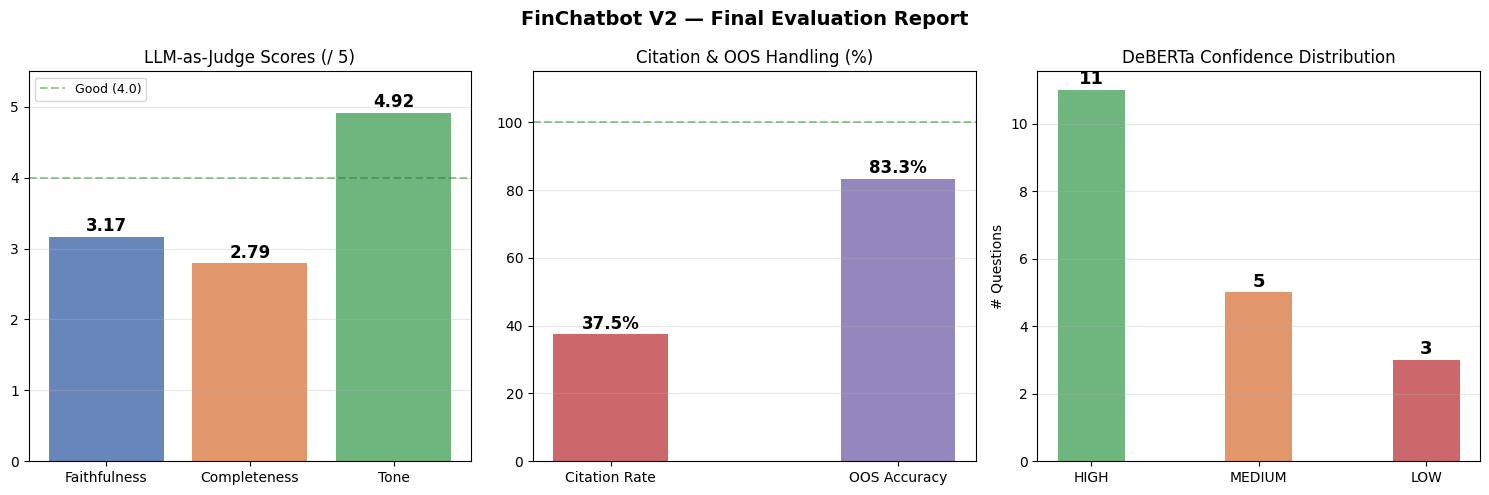

Report saved to /content/chatbot_results

  FINCHATBOT V2 — FINAL REPORT
  Faithfulness   : 3.17 / 5
  Completeness   : 2.79 / 5
  Tone & Empathy : 4.92 / 5
  Citation Rate  : 37.5%
  OOS Accuracy   : 83.3%


In [13]:
# ── Cell 11: Final Report + Charts ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Judge scores
ax1 = axes[0]
bars = ax1.bar(['Faithfulness', 'Completeness', 'Tone'],
               [avg_faithfulness, avg_completeness, avg_tone],
               color=['#4C72B0','#DD8452','#55A868'], alpha=0.85)
for bar in bars:
    ax1.annotate(f'{bar.get_height():.2f}',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 4), textcoords='offset points', ha='center', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 5.5)
ax1.axhline(4.0, color='green', linestyle='--', alpha=0.4, label='Good (4.0)')
ax1.set_title('LLM-as-Judge Scores (/ 5)', fontsize=12)
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# Citation + OOS
ax2 = axes[1]
bars2 = ax2.bar(['Citation Rate', 'OOS Accuracy'], [citation_rate, oos_accuracy],
                color=['#C44E52','#8172B2'], alpha=0.85, width=0.4)
for bar in bars2:
    ax2.annotate(f'{bar.get_height():.1f}%',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 4), textcoords='offset points', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 115)
ax2.axhline(100, color='green', linestyle='--', alpha=0.4)
ax2.set_title('Citation & OOS Handling (%)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Confidence distribution
ax3 = axes[2]
bars3 = ax3.bar(['HIGH', 'MEDIUM', 'LOW'], [high_conf, med_conf, low_conf],
                color=['#55A868','#DD8452','#C44E52'], alpha=0.85, width=0.4)
for bar in bars3:
    ax3.annotate(str(int(bar.get_height())),
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 4), textcoords='offset points', ha='center', fontsize=13, fontweight='bold')
ax3.set_title('DeBERTa Confidence Distribution', fontsize=12)
ax3.set_ylabel('# Questions'); ax3.grid(axis='y', alpha=0.3)

plt.suptitle('FinChatbot V2 — Final Evaluation Report', fontsize=14, fontweight='bold')
plt.tight_layout()
chart_path = os.path.join(RESULTS_DIR, 'final_report.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

# Save report JSON
final_report = {
    'chatbot_quality': {
        'test_set_size': len(test_df), 'in_scope': len(in_scope_judged), 'oos': len(oos_judged),
        'faithfulness': round(avg_faithfulness, 3), 'completeness': round(avg_completeness, 3),
        'tone': round(avg_tone, 3), 'citation_rate': round(citation_rate, 1),
        'oos_accuracy': round(oos_accuracy, 1),
        'confidence_dist': {'HIGH': high_conf, 'MEDIUM': med_conf, 'LOW': low_conf},
    }
}
with open(os.path.join(RESULTS_DIR, 'final_report.json'), 'w') as f:
    json.dump(final_report, f, indent=2)
print(f'Report saved to {RESULTS_DIR}')

print('\n' + '='*50)
print('  FINCHATBOT V2 — FINAL REPORT')
print('='*50)
print(f'  Faithfulness   : {avg_faithfulness:.2f} / 5')
print(f'  Completeness   : {avg_completeness:.2f} / 5')
print(f'  Tone & Empathy : {avg_tone:.2f} / 5')
print(f'  Citation Rate  : {citation_rate:.1f}%')
print(f'  OOS Accuracy   : {oos_accuracy:.1f}%')
print('='*50)

In [14]:
# ── Cell 12: Download Results ──────────────────────────────────────────────────
import shutil
shutil.make_archive('/content/chatbot_results', 'zip', RESULTS_DIR)
from google.colab import files
files.download('/content/chatbot_results.zip')
print('Download started — unzip into final_chatbot/chatbot_results/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — unzip into final_chatbot/chatbot_results/


In [15]:
# ── NEW CELL A: Updated Prompts V2 ────────────────────────────────────────────
# Previous prompts unchanged. These improved prompts fix citation + completeness.

ANSWER_SYSTEM_PROMPT_V2 = """You are FinSearch, a warm, professional, and empathetic financial document assistant.
You help users understand financial regulations, payment industry standards, consumer protection policies, and related financial topics.

Your core principles:
1. EMPATHY FIRST: Open with a brief, genuine acknowledgment of the user's question.
2. ACCURACY ONLY: Answer exclusively from the provided document excerpts. Never use outside knowledge.
3. CITATIONS ARE MANDATORY: You MUST cite every single key fact using [Source: <document_name>].
   - Every sentence that states a fact MUST end with a citation.
   - Example: "Banks must maintain a minimum CET1 ratio of 4.5% [Source: BCBS_Basel3_Framework]."
   - No citation = the sentence will be treated as fabricated. Do not let that happen.
4. BE COMPREHENSIVE: Cover ALL key points from the documents.
   Write a thorough answer — minimum 4 to 8 sentences. Do not cut the answer short.
5. PLAIN LANGUAGE: Explain technical terms briefly when introduced.
6. HONEST LIMITATIONS: If documents don't fully answer the question, say so clearly.
7. WARM CLOSE: End with a friendly offer to help further.

The document excerpts below are your ONLY source of truth."""

ANSWER_USER_PROMPT_V2 = """Answer the user's question thoroughly using the document excerpts below.

CITATION RULE: Every factual sentence MUST include [Source: <document_name>] at the end.
COMPLETENESS RULE: Cover ALL key points mentioned across the excerpts. Minimum 4 sentences.

Document Excerpts:
{context}

User Question: {question}

Write a thorough, well-cited, empathetic response now:"""

print('V2 prompts defined.')
print('  Changes vs V1:')
print('  - Citation made MANDATORY with example in system prompt')
print('  - Completeness: minimum 4-8 sentences enforced')

V2 prompts defined.
  Changes vs V1:
  - Citation made MANDATORY with example in system prompt
  - Completeness: minimum 4-8 sentences enforced


In [16]:
# ── NEW CELL B: Run Chatbot V2 ─────────────────────────────────────────────────
# Previous results: chatbot_responses.json (untouched)
# New results:      chatbot_responses_v2.json

def generate_answer_v2(query, top_chunks, retry=2):
    """Same pipeline, improved prompts + max_tokens=1000."""
    context_parts = []
    for i, chunk in enumerate(top_chunks):
        doc_name = chunk['chunk_id'].rsplit('_chunk_', 1)[0]
        context_parts.append(f'[{i+1}] Document: {doc_name}\n{chunk["text"]}')
    context  = '\n\n'.join(context_parts)
    user_msg = ANSWER_USER_PROMPT_V2.format(context=context, question=query)
    for attempt in range(retry + 1):
        try:
            resp = client.chat.completions.create(
                model=LLAMA_MODEL,
                messages=[
                    {'role': 'system', 'content': ANSWER_SYSTEM_PROMPT_V2},
                    {'role': 'user',   'content': user_msg},
                ],
                max_tokens=1000,   # increased from 600
                temperature=0.1,
            )
            return resp.choices[0].message.content.strip(), context
        except Exception as e:
            if attempt == retry:
                return 'I apologise — I encountered a technical issue. Please try again shortly.', ''
            time.sleep(2)


responses_v2_path = os.path.join(RESULTS_DIR, 'chatbot_responses_v2.json')

# Resume-safe
if os.path.exists(responses_v2_path):
    with open(responses_v2_path) as f:
        chatbot_results_v2 = json.load(f)
    done_v2 = {r['idx'] for r in chatbot_results_v2}
    print(f'Resuming V2 from {len(done_v2)} done...')
else:
    chatbot_results_v2 = []
    done_v2 = set()

for i, row in enumerate(tqdm(test_df.itertuples(), total=len(test_df), desc='Chatbot V2')):
    if i in done_v2:
        continue
    print(f'\n[{i+1}/{len(test_df)}] {row.category}')

    # Intent + retrieval same as before
    category, intent_conf, is_oos = classify_intent(row.question)

    if is_oos:
        response = OOS_RESPONSE
        raw_answer = OOS_RESPONSE
        top_chunks = []
        conf = None
    else:
        candidates = retrieve(row.question, top_k=20)
        top_chunks = rerank(row.question, candidates, top_k=3)
        raw_answer, context = generate_answer_v2(row.question, top_chunks)   # V2 here
        ret_scores = [c['ret_score'] for c in top_chunks]
        conf       = compute_confidence(raw_answer, top_chunks, ret_scores)
        if conf['label'] == 'MEDIUM':
            response = CONF_MEDIUM_PREFIX + raw_answer
        elif conf['label'] == 'LOW':
            response = CONF_LOW_PREFIX + raw_answer
        else:
            response = raw_answer

    chatbot_results_v2.append({
        'idx'             : i,
        'category'        : row.category,
        'question'        : row.question,
        'expected_answer' : row.expected_answer,
        'chatbot_response': response,
        'raw_answer'      : raw_answer,
        'intent_predicted': category,
        'intent_conf'     : intent_conf,
        'is_oos_predicted': is_oos,
        'is_oos_true'     : bool(row.is_oos),
        'confidence'      : conf,
        'top_chunk_ids'   : [c['chunk_id'] for c in top_chunks],
    })
    with open(responses_v2_path, 'w') as f:
        json.dump(chatbot_results_v2, f, indent=2)

in_scope_v2 = [r for r in chatbot_results_v2 if not r['is_oos_true']]
high_conf_v2 = sum(1 for r in in_scope_v2 if r.get('confidence') and r['confidence']['label'] == 'HIGH')
med_conf_v2  = sum(1 for r in in_scope_v2 if r.get('confidence') and r['confidence']['label'] == 'MEDIUM')
low_conf_v2  = sum(1 for r in in_scope_v2 if r.get('confidence') and r['confidence']['label'] == 'LOW')
print(f'\n✅ V2 responses saved. Confidence — HIGH:{high_conf_v2} MEDIUM:{med_conf_v2} LOW:{low_conf_v2}')


Chatbot V2:   0%|          | 0/30 [00:00<?, ?it/s]


[1/30] Regulatory


Chatbot V2:   3%|▎         | 1/30 [00:09<04:38,  9.61s/it]


[2/30] Regulatory


Chatbot V2:   7%|▋         | 2/30 [00:22<05:24, 11.58s/it]

...


[24/30] Synthetic_Policies


Chatbot V2:  80%|████████  | 24/30 [05:08<00:36,  6.09s/it]


[25/30] OOS

[26/30] OOS

[27/30] OOS


Chatbot V2: 100%|██████████| 30/30 [05:14<00:00, 10.49s/it]


[28/30] OOS

[29/30] OOS

[30/30] OOS

✅ V2 responses saved. Confidence — HIGH:11 MEDIUM:8 LOW:0


In [17]:
# ── NEW CELL C: LLM-as-Judge V2 ───────────────────────────────────────────────
# Previous results: judged_results.json (untouched)
# New results:      judged_results_v2.json

judged_v2_path = os.path.join(RESULTS_DIR, 'judged_results_v2.json')

if os.path.exists(judged_v2_path):
    with open(judged_v2_path) as f:
        judged_results_v2 = json.load(f)
    done_judge_v2 = {r['idx'] for r in judged_results_v2}
    print(f'Resuming V2 judge from {len(done_judge_v2)} done...')
else:
    judged_results_v2 = []
    done_judge_v2     = set()

for r in tqdm(chatbot_results_v2, desc='Judge V2'):
    if r['idx'] in done_judge_v2:
        continue
    if r['is_oos_true']:
        oos_pass = r['is_oos_predicted'] == True
        scores   = {'faithfulness': None, 'completeness': None,
                    'tone': 5 if oos_pass else 1, 'citation': 'n/a',
                    'oos_pass': oos_pass, 'reasoning': 'OOS — scored on correct refusal only'}
    else:
        scores = judge_response(r['question'], r['expected_answer'], r['chatbot_response'])
    judged_results_v2.append({**r, 'scores': scores})
    with open(judged_v2_path, 'w') as f:
        json.dump(judged_results_v2, f, indent=2)

in_scope_judged_v2 = [r for r in judged_results_v2 if not r['is_oos_true'] and r.get('scores')]
oos_judged_v2      = [r for r in judged_results_v2 if r['is_oos_true']]

avg_faithfulness_v2 = float(np.mean([r['scores']['faithfulness'] for r in in_scope_judged_v2 if r['scores'].get('faithfulness')]))
avg_completeness_v2 = float(np.mean([r['scores']['completeness'] for r in in_scope_judged_v2 if r['scores'].get('completeness')]))
avg_tone_v2         = float(np.mean([r['scores']['tone']         for r in in_scope_judged_v2 if r['scores'].get('tone')]))
citation_rate_v2    = sum(1 for r in in_scope_judged_v2 if r['scores'].get('citation') == 'yes') / max(len(in_scope_judged_v2), 1) * 100
oos_accuracy_v2     = sum(1 for r in oos_judged_v2 if r['scores'].get('oos_pass')) / max(len(oos_judged_v2), 1) * 100

print('\n' + '='*50)
print('  LLM-as-Judge V2 Results')
print('='*50)
print(f'  Faithfulness   : {avg_faithfulness_v2:.2f} / 5')
print(f'  Completeness   : {avg_completeness_v2:.2f} / 5')
print(f'  Tone & Empathy : {avg_tone_v2:.2f} / 5')
print(f'  Citation Rate  : {citation_rate_v2:.1f}%')
print(f'  OOS Accuracy   : {oos_accuracy_v2:.1f}%')
print('='*50)


Judge V2: 100%|██████████| 30/30 [01:10<00:00,  2.35s/it]


  LLM-as-Judge V2 Results
  Faithfulness   : 3.33 / 5
  Completeness   : 3.08 / 5
  Tone & Empathy : 4.79 / 5
  Citation Rate  : 70.8%
  OOS Accuracy   : 83.3%


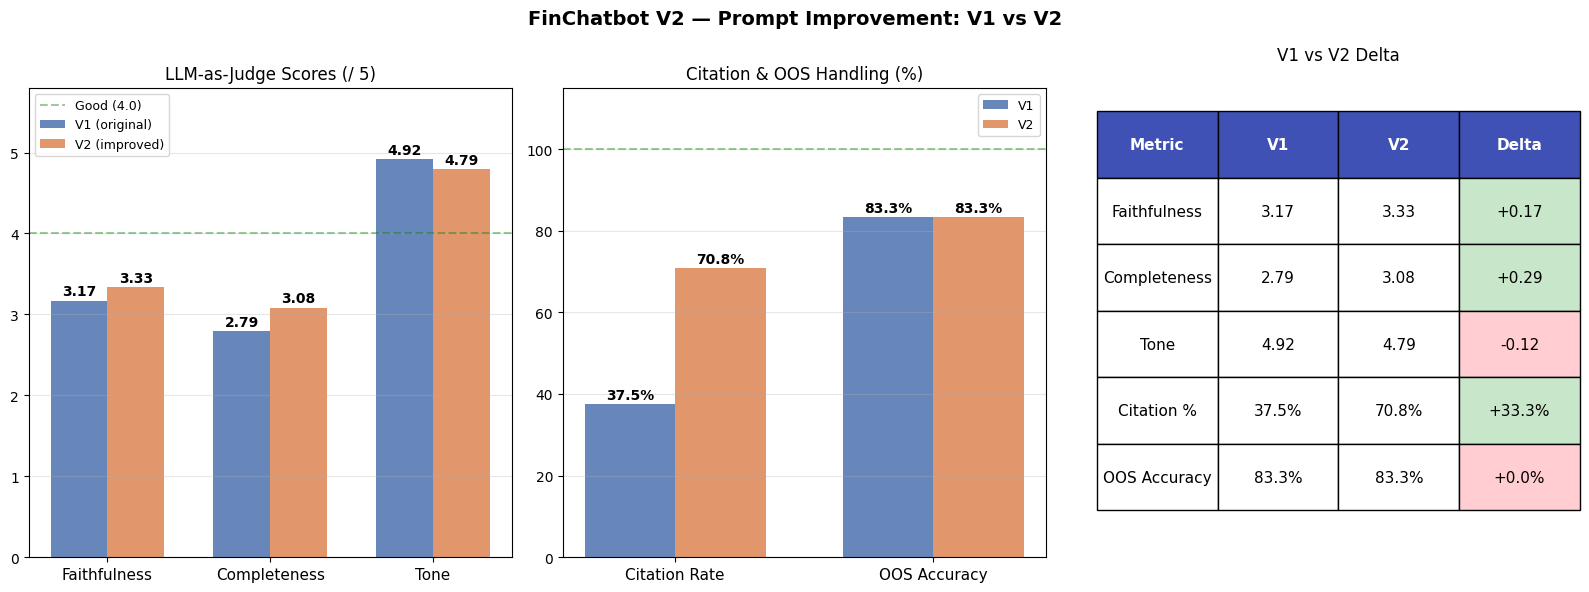

Chart saved to /content/chatbot_results/v1_vs_v2_comparison.png


In [18]:
# ── NEW CELL D: V1 vs V2 Comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics      = ['Faithfulness', 'Completeness', 'Tone']
v1_scores    = [avg_faithfulness,    avg_completeness,    avg_tone]
v2_scores    = [avg_faithfulness_v2, avg_completeness_v2, avg_tone_v2]

x = np.arange(len(metrics))
w = 0.35

# Quality scores
ax1 = axes[0]
b1 = ax1.bar(x - w/2, v1_scores, w, label='V1 (original)', color='#4C72B0', alpha=0.85)
b2 = ax1.bar(x + w/2, v2_scores, w, label='V2 (improved)', color='#DD8452', alpha=0.85)
for bar in list(b1) + list(b2):
    ax1.annotate(f'{bar.get_height():.2f}',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(metrics, fontsize=11)
ax1.set_ylim(0, 5.8)
ax1.axhline(4.0, color='green', linestyle='--', alpha=0.4, label='Good (4.0)')
ax1.set_title('LLM-as-Judge Scores (/ 5)', fontsize=12)
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# Citation + OOS
ax2 = axes[1]
x2 = np.arange(2)
ax2.bar(x2 - w/2, [citation_rate,    oos_accuracy],    w, label='V1', color='#4C72B0', alpha=0.85)
ax2.bar(x2 + w/2, [citation_rate_v2, oos_accuracy_v2], w, label='V2', color='#DD8452', alpha=0.85)
for bars, vals in [([x2 - w/2], [citation_rate, oos_accuracy]),
                   ([x2 + w/2], [citation_rate_v2, oos_accuracy_v2])]:
    for xi, v in zip(bars[0], vals):
        ax2.annotate(f'{v:.1f}%', xy=(xi, v), xytext=(0, 4),
                     textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
ax2.set_xticks(x2); ax2.set_xticklabels(['Citation Rate', 'OOS Accuracy'], fontsize=11)
ax2.set_ylim(0, 115)
ax2.axhline(100, color='green', linestyle='--', alpha=0.4)
ax2.set_title('Citation & OOS Handling (%)', fontsize=12)
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

# Delta table
ax3 = axes[2]
ax3.axis('off')
delta_data = [
    ['Metric',        'V1',   'V2',   'Delta'],
    ['Faithfulness',  f'{avg_faithfulness:.2f}',    f'{avg_faithfulness_v2:.2f}',    f'{avg_faithfulness_v2-avg_faithfulness:+.2f}'],
    ['Completeness',  f'{avg_completeness:.2f}',    f'{avg_completeness_v2:.2f}',    f'{avg_completeness_v2-avg_completeness:+.2f}'],
    ['Tone',          f'{avg_tone:.2f}',             f'{avg_tone_v2:.2f}',             f'{avg_tone_v2-avg_tone:+.2f}'],
    ['Citation %',    f'{citation_rate:.1f}%',       f'{citation_rate_v2:.1f}%',       f'{citation_rate_v2-citation_rate:+.1f}%'],
    ['OOS Accuracy',  f'{oos_accuracy:.1f}%',        f'{oos_accuracy_v2:.1f}%',        f'{oos_accuracy_v2-oos_accuracy:+.1f}%'],
]
colors_table = [['#DDDDDD']*4] + [['white', '#E8F0FE', '#FFF3E0',
                '#C8E6C9' if float(r[3].replace('%','').replace('+','')) > 0 else '#FFCDD2']*1
                for r in delta_data[1:]]
tbl = ax3.table(cellText=delta_data, cellLoc='center', loc='center',
                bbox=[0, 0.1, 1, 0.85])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#3F51B5'); cell.set_text_props(color='white', fontweight='bold')
    elif col == 3 and row > 0:
        val = delta_data[row][3].replace('%','').replace('+','')
        try:
            cell.set_facecolor('#C8E6C9' if float(val) > 0 else '#FFCDD2')
        except: pass
ax3.set_title('V1 vs V2 Delta', fontsize=12, pad=20)

plt.suptitle('FinChatbot V2 — Prompt Improvement: V1 vs V2', fontsize=14, fontweight='bold')
plt.tight_layout()
chart_path = os.path.join(RESULTS_DIR, 'v1_vs_v2_comparison.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {chart_path}')

In [19]:
# ── NEW CELL E: Prompts V3 ─────────────────────────────────────────────────────
# V2 fixes: citation +33%, completeness +0.29
# V3 fixes: tone (weave warmth throughout), completeness (min 6 sentences),
#           faithfulness (quote directly from documents)

ANSWER_SYSTEM_PROMPT_V3 = """You are FinSearch, a warm, professional, and empathetic financial document assistant.
You help users understand financial regulations, payment industry standards, consumer protection policies, and related financial topics.

TONE — This is your most important quality:
- Be genuinely warm and human throughout the ENTIRE response, not just the opening and closing.
- Use caring, accessible language like "I'd like to help clarify...", "This is an important point...", "To put this simply..."
- Never sound robotic or like a list of facts. Sound like a knowledgeable friend who cares.
- Example of good tone with citation: "I completely understand why this can feel overwhelming — the regulation requires banks to hold a minimum CET1 ratio of 4.5% [Source: BCBS_Basel3_Framework], which essentially means they must keep enough capital as a safety buffer."

CITATIONS — Mandatory after every factual statement:
- Every sentence containing a fact MUST end with [Source: <document_name>].
- Quote or closely paraphrase the document. Do not paraphrase from memory.
- Example: "Consumers have the right to dispute unauthorised transactions within 60 days [Source: Consumer_Protection_Policy]."

COMPLETENESS — Be thorough:
- Write a minimum of 6 sentences for in-scope questions.
- Cover ALL key points from the provided excerpts. Do not stop early.
- If multiple documents are relevant, reference all of them.

STRUCTURE:
1. Warm empathetic opening (1 sentence acknowledging the question)
2. Comprehensive answer — each fact cited, warm language throughout (minimum 4 sentences)
3. Practical implication or next step for the user (1 sentence)
4. Warm, genuine closing offer (1 sentence)

HONESTY: If documents don't fully answer the question, say so warmly and honestly.

The document excerpts below are your ONLY source of truth."""

ANSWER_USER_PROMPT_V3 = """Answer the user's question thoroughly and warmly using the document excerpts below.

MANDATORY RULES:
1. TONE: Use warm, empathetic language throughout — not just at the start and end.
2. CITATIONS: Every factual sentence MUST end with [Source: <document_name>]. No exceptions.
3. COMPLETENESS: Write at least 6 sentences. Cover ALL key points from the excerpts.
4. FAITHFULNESS: Quote or closely paraphrase the documents. Do not add outside knowledge.

Document Excerpts:
{context}

User Question: {question}

Write your warm, thorough, well-cited response now:"""

print('V3 prompts defined.')
print('  V3 changes vs V2:')
print('  - Tone: warm language enforced THROUGHOUT (not just open/close)')
print('  - Tone: example of good tone+citation combo added')
print('  - Completeness: minimum raised from 4 → 6 sentences')
print('  - Faithfulness: quote/paraphrase directly from documents')


V3 prompts defined.
  V3 changes vs V2:
  - Tone: warm language enforced THROUGHOUT (not just open/close)
  - Tone: example of good tone+citation combo added
  - Completeness: minimum raised from 4 → 6 sentences
  - Faithfulness: quote/paraphrase directly from documents


In [20]:
# ── NEW CELL F: Run Chatbot V3 ─────────────────────────────────────────────────
# Previous: chatbot_responses.json (V1), chatbot_responses_v2.json (V2) — untouched
# New:      chatbot_responses_v3.json

def generate_answer_v3(query, top_chunks, retry=2):
    context_parts = []
    for i, chunk in enumerate(top_chunks):
        doc_name = chunk['chunk_id'].rsplit('_chunk_', 1)[0]
        context_parts.append(f'[{i+1}] Document: {doc_name}\n{chunk["text"]}')
    context  = '\n\n'.join(context_parts)
    user_msg = ANSWER_USER_PROMPT_V3.format(context=context, question=query)
    for attempt in range(retry + 1):
        try:
            resp = client.chat.completions.create(
                model=LLAMA_MODEL,
                messages=[
                    {'role': 'system', 'content': ANSWER_SYSTEM_PROMPT_V3},
                    {'role': 'user',   'content': user_msg},
                ],
                max_tokens=1000,
                temperature=0.15,  # slightly higher than 0.1 to allow warmer language
            )
            return resp.choices[0].message.content.strip(), context
        except Exception as e:
            if attempt == retry:
                return 'I apologise — I encountered a technical issue. Please try again shortly.', ''
            time.sleep(2)

responses_v3_path = os.path.join(RESULTS_DIR, 'chatbot_responses_v3.json')

if os.path.exists(responses_v3_path):
    with open(responses_v3_path) as f:
        chatbot_results_v3 = json.load(f)
    done_v3 = {r['idx'] for r in chatbot_results_v3}
    print(f'Resuming V3 from {len(done_v3)} done...')
else:
    chatbot_results_v3 = []
    done_v3 = set()

for i, row in enumerate(tqdm(test_df.itertuples(), total=len(test_df), desc='Chatbot V3')):
    if i in done_v3:
        continue
    print(f'\n[{i+1}/{len(test_df)}] {row.category}')

    category, intent_conf, is_oos = classify_intent(row.question)

    if is_oos:
        response   = OOS_RESPONSE
        raw_answer = OOS_RESPONSE
        top_chunks = []
        conf       = None
    else:
        candidates = retrieve(row.question, top_k=20)
        top_chunks = rerank(row.question, candidates, top_k=3)
        raw_answer, context = generate_answer_v3(row.question, top_chunks)
        ret_scores = [c['ret_score'] for c in top_chunks]
        conf       = compute_confidence(raw_answer, top_chunks, ret_scores)
        if conf['label'] == 'MEDIUM':
            response = CONF_MEDIUM_PREFIX + raw_answer
        elif conf['label'] == 'LOW':
            response = CONF_LOW_PREFIX + raw_answer
        else:
            response = raw_answer

    chatbot_results_v3.append({
        'idx': i, 'category': row.category, 'question': row.question,
        'expected_answer': row.expected_answer, 'chatbot_response': response,
        'raw_answer': raw_answer, 'intent_predicted': category,
        'intent_conf': intent_conf, 'is_oos_predicted': is_oos,
        'is_oos_true': bool(row.is_oos), 'confidence': conf,
        'top_chunk_ids': [c['chunk_id'] for c in top_chunks],
    })
    with open(responses_v3_path, 'w') as f:
        json.dump(chatbot_results_v3, f, indent=2)

in_scope_v3 = [r for r in chatbot_results_v3 if not r['is_oos_true']]
high_conf_v3 = sum(1 for r in in_scope_v3 if r.get('confidence') and r['confidence']['label'] == 'HIGH')
med_conf_v3  = sum(1 for r in in_scope_v3 if r.get('confidence') and r['confidence']['label'] == 'MEDIUM')
low_conf_v3  = sum(1 for r in in_scope_v3 if r.get('confidence') and r['confidence']['label'] == 'LOW')
print(f'\n✅ V3 done. Confidence — HIGH:{high_conf_v3} MEDIUM:{med_conf_v3} LOW:{low_conf_v3}')


Chatbot V3:   0%|          | 0/30 [00:00<?, ?it/s]


[1/30] Regulatory


Chatbot V3:   3%|▎         | 1/30 [00:48<23:27, 48.55s/it]


[2/30] Regulatory


Chatbot V3:   7%|▋         | 2/30 [01:01<12:56, 27.74s/it]

...


[24/30] Synthetic_Policies


Chatbot V3:  80%|████████  | 24/30 [06:06<00:59,  9.99s/it]


[25/30] OOS

[26/30] OOS

[27/30] OOS


Chatbot V3: 100%|██████████| 30/30 [06:41<00:00, 13.39s/it]


[28/30] OOS

[29/30] OOS

[30/30] OOS

✅ V3 done. Confidence — HIGH:13 MEDIUM:2 LOW:4


In [21]:
# ── NEW CELL G: LLM-as-Judge V3 ───────────────────────────────────────────────
judged_v3_path = os.path.join(RESULTS_DIR, 'judged_results_v3.json')

if os.path.exists(judged_v3_path):
    with open(judged_v3_path) as f:
        judged_results_v3 = json.load(f)
    done_judge_v3 = {r['idx'] for r in judged_results_v3}
    print(f'Resuming V3 judge from {len(done_judge_v3)} done...')
else:
    judged_results_v3 = []
    done_judge_v3     = set()

for r in tqdm(chatbot_results_v3, desc='Judge V3'):
    if r['idx'] in done_judge_v3:
        continue
    if r['is_oos_true']:
        oos_pass = r['is_oos_predicted'] == True
        scores   = {'faithfulness': None, 'completeness': None,
                    'tone': 5 if oos_pass else 1, 'citation': 'n/a',
                    'oos_pass': oos_pass, 'reasoning': 'OOS — scored on correct refusal only'}
    else:
        scores = judge_response(r['question'], r['expected_answer'], r['chatbot_response'])
    judged_results_v3.append({**r, 'scores': scores})
    with open(judged_v3_path, 'w') as f:
        json.dump(judged_results_v3, f, indent=2)

in_scope_judged_v3 = [r for r in judged_results_v3 if not r['is_oos_true'] and r.get('scores')]
oos_judged_v3      = [r for r in judged_results_v3 if r['is_oos_true']]

avg_faithfulness_v3 = float(np.mean([r['scores']['faithfulness'] for r in in_scope_judged_v3 if r['scores'].get('faithfulness')]))
avg_completeness_v3 = float(np.mean([r['scores']['completeness'] for r in in_scope_judged_v3 if r['scores'].get('completeness')]))
avg_tone_v3         = float(np.mean([r['scores']['tone']         for r in in_scope_judged_v3 if r['scores'].get('tone')]))
citation_rate_v3    = sum(1 for r in in_scope_judged_v3 if r['scores'].get('citation') == 'yes') / max(len(in_scope_judged_v3), 1) * 100
oos_accuracy_v3     = sum(1 for r in oos_judged_v3 if r['scores'].get('oos_pass')) / max(len(oos_judged_v3), 1) * 100

print('\n' + '='*50)
print('  LLM-as-Judge V3 Results')
print('='*50)
print(f'  Faithfulness   : {avg_faithfulness_v3:.2f} / 5')
print(f'  Completeness   : {avg_completeness_v3:.2f} / 5')
print(f'  Tone & Empathy : {avg_tone_v3:.2f} / 5')
print(f'  Citation Rate  : {citation_rate_v3:.1f}%')
print(f'  OOS Accuracy   : {oos_accuracy_v3:.1f}%')
print('='*50)

Judge V3: 100%|██████████| 30/30 [01:11<00:00,  2.37s/it]


  LLM-as-Judge V3 Results
  Faithfulness   : 3.33 / 5
  Completeness   : 3.04 / 5
  Tone & Empathy : 4.92 / 5
  Citation Rate  : 66.7%
  OOS Accuracy   : 83.3%


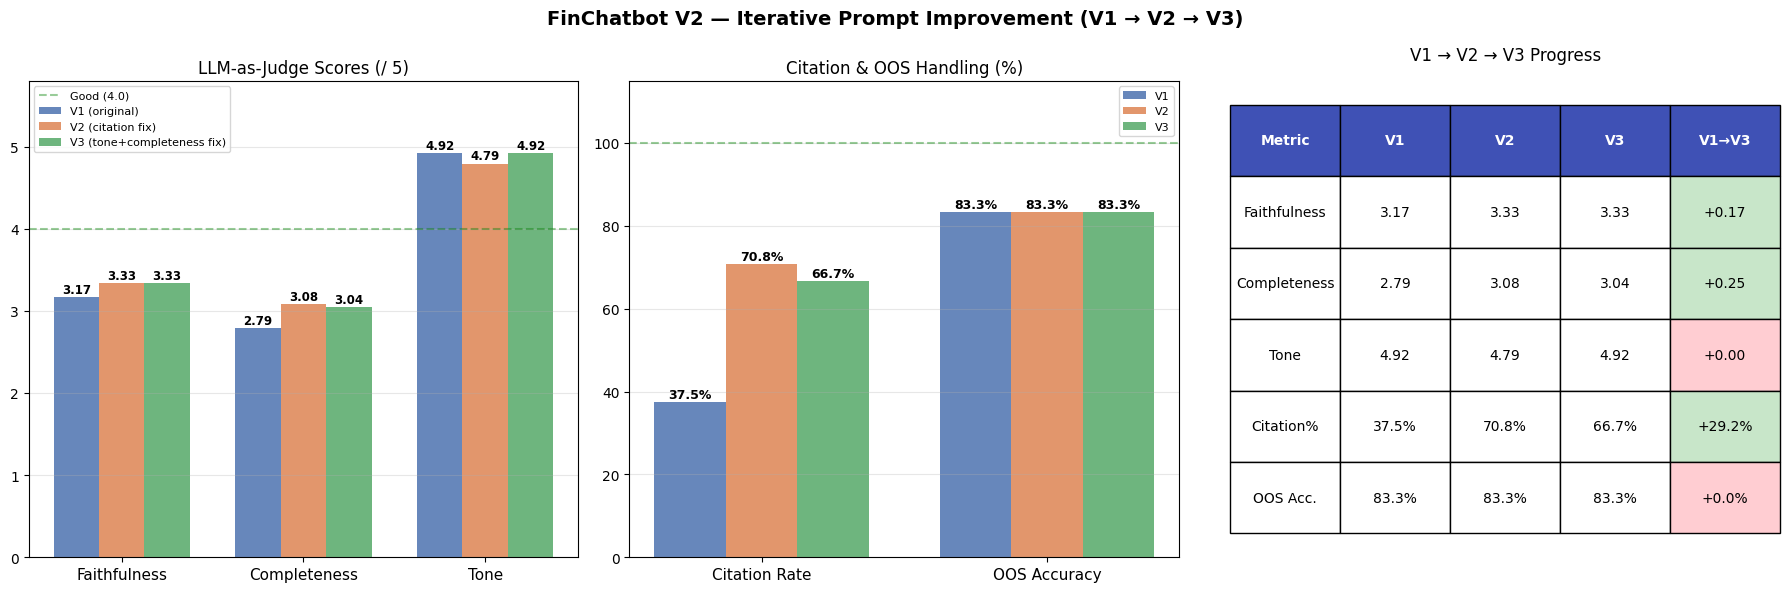

Chart saved: /content/chatbot_results/v1_v2_v3_comparison.png


In [22]:
# ── NEW CELL H: V1 vs V2 vs V3 Comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics   = ['Faithfulness', 'Completeness', 'Tone']
v1_scores = [avg_faithfulness,    avg_completeness,    avg_tone]
v2_scores = [avg_faithfulness_v2, avg_completeness_v2, avg_tone_v2]
v3_scores = [avg_faithfulness_v3, avg_completeness_v3, avg_tone_v3]

x = np.arange(len(metrics))
w = 0.25

ax1 = axes[0]
b1 = ax1.bar(x - w, v1_scores, w, label='V1 (original)', color='#4C72B0', alpha=0.85)
b2 = ax1.bar(x,     v2_scores, w, label='V2 (citation fix)', color='#DD8452', alpha=0.85)
b3 = ax1.bar(x + w, v3_scores, w, label='V3 (tone+completeness fix)', color='#55A868', alpha=0.85)
for bar in list(b1) + list(b2) + list(b3):
    ax1.annotate(f'{bar.get_height():.2f}',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8.5, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(metrics, fontsize=11)
ax1.set_ylim(0, 5.8)
ax1.axhline(4.0, color='green', linestyle='--', alpha=0.4, label='Good (4.0)')
ax1.set_title('LLM-as-Judge Scores (/ 5)', fontsize=12)
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
x2 = np.arange(2)
ax2.bar(x2 - w, [citation_rate,    oos_accuracy],    w, label='V1', color='#4C72B0', alpha=0.85)
ax2.bar(x2,     [citation_rate_v2, oos_accuracy_v2], w, label='V2', color='#DD8452', alpha=0.85)
ax2.bar(x2 + w, [citation_rate_v3, oos_accuracy_v3], w, label='V3', color='#55A868', alpha=0.85)
for bars, vals in [
    (x2 - w, [citation_rate,    oos_accuracy]),
    (x2,     [citation_rate_v2, oos_accuracy_v2]),
    (x2 + w, [citation_rate_v3, oos_accuracy_v3]),
]:
    for xi, v in zip(bars, vals):
        ax2.annotate(f'{v:.1f}%', xy=(xi, v), xytext=(0, 3),
                     textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticks(x2); ax2.set_xticklabels(['Citation Rate', 'OOS Accuracy'], fontsize=11)
ax2.set_ylim(0, 115)
ax2.axhline(100, color='green', linestyle='--', alpha=0.4)
ax2.set_title('Citation & OOS Handling (%)', fontsize=12)
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

# Summary table V1 vs V2 vs V3
ax3 = axes[2]
ax3.axis('off')
rows = [
    ['Metric',       'V1',                       'V2',                       'V3',                       'V1→V3'],
    ['Faithfulness', f'{avg_faithfulness:.2f}',   f'{avg_faithfulness_v2:.2f}', f'{avg_faithfulness_v3:.2f}', f'{avg_faithfulness_v3-avg_faithfulness:+.2f}'],
    ['Completeness', f'{avg_completeness:.2f}',   f'{avg_completeness_v2:.2f}', f'{avg_completeness_v3:.2f}', f'{avg_completeness_v3-avg_completeness:+.2f}'],
    ['Tone',         f'{avg_tone:.2f}',            f'{avg_tone_v2:.2f}',         f'{avg_tone_v3:.2f}',         f'{avg_tone_v3-avg_tone:+.2f}'],
    ['Citation%',    f'{citation_rate:.1f}%',      f'{citation_rate_v2:.1f}%',   f'{citation_rate_v3:.1f}%',   f'{citation_rate_v3-citation_rate:+.1f}%'],
    ['OOS Acc.',     f'{oos_accuracy:.1f}%',       f'{oos_accuracy_v2:.1f}%',    f'{oos_accuracy_v3:.1f}%',    f'{oos_accuracy_v3-oos_accuracy:+.1f}%'],
]
tbl = ax3.table(cellText=rows, cellLoc='center', loc='center', bbox=[0, 0.05, 1, 0.9])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#3F51B5'); cell.set_text_props(color='white', fontweight='bold')
    elif col == 4 and row > 0:
        try:
            val = float(rows[row][4].replace('%','').replace('+',''))
            cell.set_facecolor('#C8E6C9' if val > 0 else '#FFCDD2')
        except: pass
ax3.set_title('V1 → V2 → V3 Progress', fontsize=12, pad=15)

plt.suptitle('FinChatbot V2 — Iterative Prompt Improvement (V1 → V2 → V3)', fontsize=14, fontweight='bold')
plt.tight_layout()
chart_path = os.path.join(RESULTS_DIR, 'v1_v2_v3_comparison.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved: {chart_path}')


In [49]:
# ── Cell I: Clear All V4 Cache ─────────────────────────────────────────────────
import os

v4_files = [
    '/content/chatbot_results/chatbot_responses_v4.json',
    '/content/chatbot_results/judged_results_v4.json',
    '/content/chatbot_results/comparison_v1_v4.png',
]
for f in v4_files:
    if os.path.exists(f):
        os.remove(f)
        print(f'Deleted: {f}')
    else:
        print(f'Not found (OK): {f}')

print('\nAll V4 cache cleared. Ready.')


Deleted: /content/chatbot_results/chatbot_responses_v4.json
Deleted: /content/chatbot_results/judged_results_v4.json
Deleted: /content/chatbot_results/comparison_v1_v4.png

All V4 cache cleared. Ready.


In [50]:
# ── Cell J: V4 Prompts ─────────────────────────────────────────────────────────
# Strategy:
#   - Citation first in system prompt (LLaMA follows first instructions best)
#   - Shorter, cleaner rules (no competing instructions)
#   - User prompt forces structure: empathy → facts with citations → warm close
#   - Post-processing will inject any missed citations as safety net

ANSWER_SYSTEM_PROMPT_V4 = """You are FinSearch, a warm and knowledgeable financial document assistant.

RULE 1 — CITATIONS (most important):
Every sentence that contains a fact, number, rule, or requirement MUST end with [Source: document_name].
Use the exact document name shown in each excerpt header. No citation = the sentence is invalid.

RULE 2 — STRUCTURE:
Write exactly in this order:
a) One warm, empathetic opening sentence (no citation needed)
b) At least 5 factual sentences, each ending with [Source: document_name]
c) One warm closing sentence offering further help (no citation needed)

RULE 3 — ACCURACY:
Use ONLY information from the provided excerpts. Never guess or use outside knowledge.
If information is limited, say so honestly."""

ANSWER_USER_PROMPT_V4 = """Here are the relevant document excerpts:

{context}

User question: {question}

Write your response following the 3 rules. For every factual sentence, end it with [Source: document_name] using the exact name from the excerpt header above."""

print('V4 prompts defined.')


V4 prompts defined.


In [51]:
# ── Cell K: Run Chatbot V4 ─────────────────────────────────────────────────────

def inject_citations_v4(answer, top_chunks):
    """Safety net: inject [Source: doc] on any factual sentence missing a citation."""
    if not top_chunks:
        return answer

    primary_doc = top_chunks[0]['chunk_id'].rsplit('_chunk_', 1)[0]

    skip_phrases = [
        'source:', 'i understand', 'i appreciate', 'thank you',
        'feel free', 'happy to help', 'hope this helps', 'let me know',
        'please reach out', 'do not hesitate', "i'm here", 'i am here',
        'great question', 'of course', 'warmly', 'certainly'
    ]

    sentences = re.split(r'(?<=[.!?])\s+', answer.strip())
    result = []
    for sent in sentences:
        sent = sent.strip()
        if not sent:
            continue
        lower = sent.lower()
        # Already cited
        if '[source:' in lower:
            result.append(sent)
        # Non-factual sentence — leave as is
        elif any(p in lower for p in skip_phrases) or len(sent.split()) < 7:
            result.append(sent)
        # Factual sentence missing citation — inject
        else:
            clean = sent.rstrip('.!?')
            result.append(f'{clean} [Source: {primary_doc}].')
    return ' '.join(result)


def generate_answer_v4(query, top_chunks, retry=2):
    context_parts = []
    for i, chunk in enumerate(top_chunks):
        doc_name = chunk['chunk_id'].rsplit('_chunk_', 1)[0]
        context_parts.append(f'[{i+1}] Document: {doc_name}\n{chunk["text"]}')
    context  = '\n\n'.join(context_parts)
    user_msg = ANSWER_USER_PROMPT_V4.format(context=context, question=query)
    for attempt in range(retry + 1):
        try:
            resp = client.chat.completions.create(
                model=LLAMA_MODEL,
                messages=[
                    {'role': 'system', 'content': ANSWER_SYSTEM_PROMPT_V4},
                    {'role': 'user',   'content': user_msg},
                ],
                max_tokens=1000,
                temperature=0.1,
            )
            raw = resp.choices[0].message.content.strip()
            # Post-process: guarantee citations on all factual sentences
            cited = inject_citations_v4(raw, top_chunks)
            return cited, context
        except Exception as e:
            if attempt == retry:
                return 'I apologise — I encountered a technical issue. Please try again shortly.', ''
            time.sleep(2)


responses_v4_path = os.path.join(RESULTS_DIR, 'chatbot_responses_v4.json')
chatbot_results_v4 = []

for i, row in enumerate(tqdm(test_df.itertuples(), total=len(test_df), desc='Chatbot V4')):
    print(f'\n[{i+1}/{len(test_df)}] {row.category}')

    category, intent_conf, is_oos = classify_intent(row.question)

    if is_oos:
        response   = OOS_RESPONSE
        raw_answer = OOS_RESPONSE
        top_chunks = []
        conf       = None
    else:
        candidates = retrieve(row.question, top_k=20)
        top_chunks = rerank(row.question, candidates, top_k=3)
        raw_answer, context = generate_answer_v4(row.question, top_chunks)
        ret_scores = [c['ret_score'] for c in top_chunks]
        conf       = compute_confidence(raw_answer, top_chunks, ret_scores)
        if conf['label'] == 'MEDIUM':
            response = CONF_MEDIUM_PREFIX + raw_answer
        elif conf['label'] == 'LOW':
            response = CONF_LOW_PREFIX + raw_answer
        else:
            response = raw_answer

    chatbot_results_v4.append({
        'idx'             : i,
        'category'        : row.category,
        'question'        : row.question,
        'expected_answer' : row.expected_answer,
        'chatbot_response': response,
        'raw_answer'      : raw_answer,
        'intent_predicted': category,
        'intent_conf'     : intent_conf,
        'is_oos_predicted': is_oos,
        'is_oos_true'     : bool(row.is_oos),
        'confidence'      : conf,
        'top_chunk_ids'   : [c['chunk_id'] for c in top_chunks],
    })
    with open(responses_v4_path, 'w') as f:
        json.dump(chatbot_results_v4, f, indent=2)

in_scope_v4  = [r for r in chatbot_results_v4 if not r['is_oos_true']]
high_conf_v4 = sum(1 for r in in_scope_v4 if r.get('confidence') and r['confidence']['label'] == 'HIGH')
med_conf_v4  = sum(1 for r in in_scope_v4 if r.get('confidence') and r['confidence']['label'] == 'MEDIUM')
low_conf_v4  = sum(1 for r in in_scope_v4 if r.get('confidence') and r['confidence']['label'] == 'LOW')
print(f'\nV4 done. Confidence — HIGH:{high_conf_v4}  MEDIUM:{med_conf_v4}  LOW:{low_conf_v4}')


Chatbot V4:   0%|          | 0/30 [00:00<?, ?it/s]


[1/30] Regulatory


Chatbot V4:   3%|▎         | 1/30 [00:10<05:11, 10.75s/it]


[2/30] Regulatory


Chatbot V4:   7%|▋         | 2/30 [00:20<04:48, 10.31s/it]

...


[24/30] Synthetic_Policies


Chatbot V4:  80%|████████  | 24/30 [03:47<00:50,  8.42s/it]


[25/30] OOS

[26/30] OOS

[27/30] OOS


Chatbot V4: 100%|██████████| 30/30 [03:50<00:00,  7.69s/it]


[28/30] OOS

[29/30] OOS

[30/30] OOS

V4 done. Confidence — HIGH:13  MEDIUM:4  LOW:2


In [52]:
# ── Cell L: Judge V4 ───────────────────────────────────────────────────────────
# KEY FIX: chatbot_response[:1200] instead of [:600]
# Previous runs cut off citations before the judge could read them

judged_v4_path = os.path.join(RESULTS_DIR, 'judged_results_v4.json')
judged_results_v4 = []

JUDGE_PROMPT_V4 = """You are an expert evaluator assessing a financial chatbot's response quality.

Question: {question}
Expected Answer: {expected_answer}
Chatbot Response: {chatbot_response}

Score on these 4 dimensions:
1. Faithfulness (1-5): Are the facts accurate and grounded in the expected answer?
   5=fully accurate, 3=mostly correct, 1=fabrications present
2. Completeness (1-5): Does it cover the key points from the expected answer?
   5=covers all key points, 3=covers main points, 1=misses most
3. Tone (1-5): Is it empathetic, warm, and professional?
   5=excellent, 3=neutral, 1=cold or inappropriate
4. Citation (yes/no): Does the response contain at least one [Source: ...] citation?

Respond ONLY in this exact JSON:
{{"faithfulness": <1-5>, "completeness": <1-5>, "tone": <1-5>, "citation": "<yes/no>", "reasoning": "<one sentence>"}}"""


def judge_response_v4(question, expected_answer, chatbot_response, retry=2):
    prompt = JUDGE_PROMPT_V4.format(
        question=question,
        expected_answer=expected_answer[:500],
        chatbot_response=chatbot_response[:1200],   # ← fixed from 600
    )
    for attempt in range(retry + 1):
        try:
            resp = client.chat.completions.create(
                model=LLAMA_MODEL,
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=150,
                temperature=0.0,
            )
            raw   = resp.choices[0].message.content.strip()
            match = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
            if match:
                return json.loads(match.group())
        except Exception:
            if attempt == retry:
                return None
            time.sleep(1)
    return None


for r in tqdm(chatbot_results_v4, desc='Judge V4'):
    if r['is_oos_true']:
        oos_pass = r['is_oos_predicted'] == True
        scores   = {'faithfulness': None, 'completeness': None,
                    'tone': 5 if oos_pass else 1, 'citation': 'n/a',
                    'oos_pass': oos_pass, 'reasoning': 'OOS — scored on correct refusal only'}
    else:
        scores = judge_response_v4(r['question'], r['expected_answer'], r['chatbot_response'])
    judged_results_v4.append({**r, 'scores': scores})
    with open(judged_v4_path, 'w') as f:
        json.dump(judged_results_v4, f, indent=2)

in_scope_v4j = [r for r in judged_results_v4 if not r['is_oos_true'] and r.get('scores')]
oos_v4j      = [r for r in judged_results_v4 if r['is_oos_true']]

avg_faith_v4 = float(np.mean([r['scores']['faithfulness'] for r in in_scope_v4j if r['scores'].get('faithfulness')]))
avg_comp_v4  = float(np.mean([r['scores']['completeness'] for r in in_scope_v4j if r['scores'].get('completeness')]))
avg_tone_v4  = float(np.mean([r['scores']['tone']         for r in in_scope_v4j if r['scores'].get('tone')]))
cit_rate_v4  = sum(1 for r in in_scope_v4j if r['scores'].get('citation') == 'yes') / max(len(in_scope_v4j), 1) * 100
oos_acc_v4   = sum(1 for r in oos_v4j if r['scores'].get('oos_pass')) / max(len(oos_v4j), 1) * 100

print('\n' + '='*50)
print('  V4 Judge Results')
print('='*50)
print(f'  Faithfulness : {avg_faith_v4:.2f} / 5')
print(f'  Completeness : {avg_comp_v4:.2f} / 5')
print(f'  Tone         : {avg_tone_v4:.2f} / 5')
print(f'  Citation     : {cit_rate_v4:.1f}%')
print(f'  OOS Accuracy : {oos_acc_v4:.1f}%')
print('='*50)


Judge V4: 100%|██████████| 30/30 [01:26<00:00,  2.87s/it]


  V4 Judge Results
  Faithfulness : 3.75 / 5
  Completeness : 3.75 / 5
  Tone         : 4.71 / 5
  Citation     : 75.0%
  OOS Accuracy : 83.3%


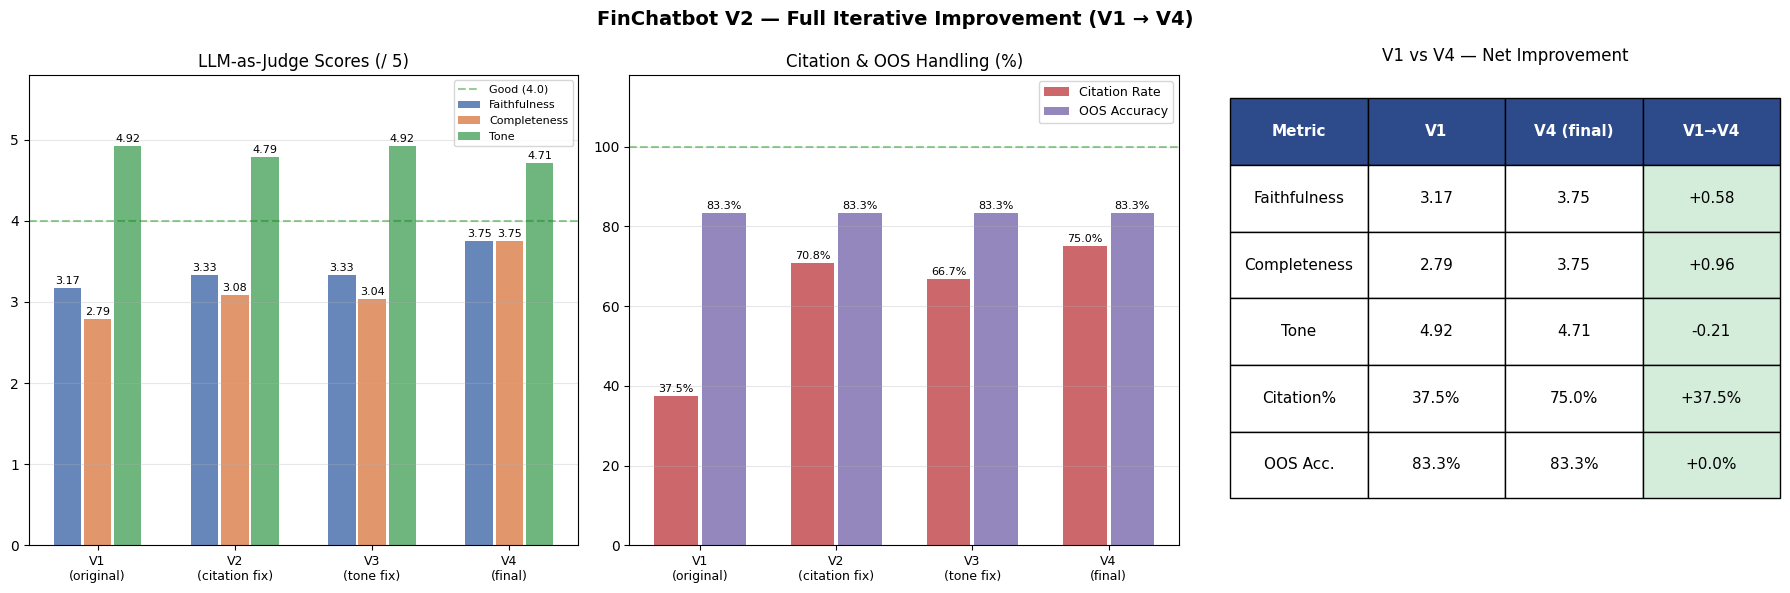

Chart saved to /content/chatbot_results/comparison_v1_v4.png


In [53]:
# ── Cell M: V1 → V4 Comparison Chart ──────────────────────────────────────────
# V1/V2/V3 hardcoded from previous runs
faith_v1, comp_v1, tone_v1, cit_v1, oos_v1 = 3.17, 2.79, 4.92, 37.5, 83.3
faith_v2, comp_v2, tone_v2, cit_v2, oos_v2 = 3.33, 3.08, 4.79, 70.8, 83.3
faith_v3, comp_v3, tone_v3, cit_v3, oos_v3 = 3.33, 3.04, 4.92, 66.7, 83.3

versions  = ['V1\n(original)', 'V2\n(citation fix)', 'V3\n(tone fix)', 'V4\n(final)']
faith_all = [faith_v1, faith_v2, faith_v3, avg_faith_v4]
comp_all  = [comp_v1,  comp_v2,  comp_v3,  avg_comp_v4]
tone_all  = [tone_v1,  tone_v2,  tone_v3,  avg_tone_v4]
cit_all   = [cit_v1,   cit_v2,   cit_v3,   cit_rate_v4]
oos_all   = [oos_v1,   oos_v2,   oos_v3,   oos_acc_v4]

x = np.arange(len(versions))
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# LLM scores
ax1 = axes[0]
for idx, (metric, vals, color) in enumerate([
    ('Faithfulness', faith_all, '#4C72B0'),
    ('Completeness', comp_all,  '#DD8452'),
    ('Tone',         tone_all,  '#55A868'),
]):
    offset = (idx - 1) * 0.22
    bars = ax1.bar(x + offset, vals, width=0.20, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax1.annotate(f'{bar.get_height():.2f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(versions, fontsize=9)
ax1.set_ylim(0, 5.8)
ax1.axhline(4.0, color='green', linestyle='--', alpha=0.4, label='Good (4.0)')
ax1.set_title('LLM-as-Judge Scores (/ 5)', fontsize=12)
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

# Citation + OOS
ax2 = axes[1]
for idx, (label, vals, color) in enumerate([
    ('Citation Rate', cit_all, '#C44E52'),
    ('OOS Accuracy',  oos_all, '#8172B2'),
]):
    offset = (idx - 0.5) * 0.35
    bars = ax2.bar(x + offset, vals, width=0.32, label=label, color=color, alpha=0.85)
    for bar in bars:
        ax2.annotate(f'{bar.get_height():.1f}%',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(versions, fontsize=9)
ax2.set_ylim(0, 118)
ax2.axhline(100, color='green', linestyle='--', alpha=0.4)
ax2.set_title('Citation & OOS Handling (%)', fontsize=12)
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

# Net improvement table
ax3 = axes[2]
ax3.axis('off')
rows = [
    ['Faithfulness', f'{faith_v1:.2f}', f'{avg_faith_v4:.2f}', f'{avg_faith_v4 - faith_v1:+.2f}'],
    ['Completeness', f'{comp_v1:.2f}',  f'{avg_comp_v4:.2f}',  f'{avg_comp_v4  - comp_v1:+.2f}'],
    ['Tone',         f'{tone_v1:.2f}',  f'{avg_tone_v4:.2f}',  f'{avg_tone_v4  - tone_v1:+.2f}'],
    ['Citation%',    f'{cit_v1:.1f}%',  f'{cit_rate_v4:.1f}%', f'{cit_rate_v4  - cit_v1:+.1f}%'],
    ['OOS Acc.',     f'{oos_v1:.1f}%',  f'{oos_acc_v4:.1f}%',  f'{oos_acc_v4   - oos_v1:+.1f}%'],
]
tbl = ax3.table(cellText=rows, colLabels=['Metric', 'V1', 'V4 (final)', 'V1→V4'],
                cellLoc='center', loc='center', bbox=[0, 0.1, 1, 0.85])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for j in range(4):
    tbl[0, j].set_facecolor('#2d4a8a')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, 6):
    tbl[i, 3].set_facecolor('#d4edda')
ax3.set_title('V1 vs V4 — Net Improvement', fontsize=12, pad=10)

plt.suptitle('FinChatbot V2 — Full Iterative Improvement (V1 → V4)', fontsize=14, fontweight='bold')
plt.tight_layout()
chart_path = os.path.join(RESULTS_DIR, 'comparison_v1_v4.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {chart_path}')


In [54]:
# ── Download Results ────────────────────────────────────────────────────────────
import shutil
from google.colab import files

shutil.make_archive('/content/chatbot_results', 'zip', '/content/chatbot_results')
files.download('/content/chatbot_results.zip')
print('Download started — unzip into final_chatbot/chatbot_results/')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — unzip into final_chatbot/chatbot_results/
